# ShopEase Europe - Notebook 6: Topic Modelling
**Project:** Sentiment Analysis for Customer Feedback
**Dataset:** amazon_reviews_cleaned.csv

This notebook applies Latent Dirichlet Allocation to the cleaned review corpus to discover recurring discussion themes. The topics are labelled based on their dominant words and the sentiment distribution within each topic is examined to identify the themes most associated with customer dissatisfaction.

In [10]:
%pip install pandas numpy matplotlib seaborn scikit-learn nltk textblob --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 6.1 Load Data

In [11]:
import re, pickle, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings('ignore')
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from nltk.sentiment.vader import SentimentIntensityAnalyzer
for pkg in ['punkt','stopwords','wordnet','punkt_tab','vader_lexicon','omw-1.4']:
    nltk.download(pkg, quiet=True)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
PALETTE = {'Positive': '#2ecc71', 'Neutral': '#3498db', 'Negative': '#e74c3c'}

COUNTRY_NAMES = {
    'US': 'United States', 'GB': 'United Kingdom', 'CA': 'Canada',
    'IN': 'India', 'IE': 'Ireland', 'DK': 'Denmark', 'NL': 'Netherlands',
    'AU': 'Australia', 'DE': 'Germany', 'IT': 'Italy', 'FR': 'France',
    'SE': 'Sweden', 'ES': 'Spain', 'AE': 'United Arab Emirates',
    'PK': 'Pakistan', 'IL': 'Israel', 'NZ': 'New Zealand', 'BE': 'Belgium',
    'ZA': 'South Africa', 'PH': 'Philippines', 'JP': 'Japan', 'MX': 'Mexico',
    'SG': 'Singapore', 'BR': 'Brazil', 'NG': 'Nigeria', 'KE': 'Kenya',
    'TR': 'Turkey', 'PL': 'Poland', 'SA': 'Saudi Arabia', 'NO': 'Norway'
}

df = pd.read_csv(r'C:\Users\ifech\OneDrive\Desktop\sentiment_analysis\data\processed\amazon_reviews_cleaned_processed.csv')
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
for col in ['sentiment','country','product_category']:
    df[col] = df[col].str.strip()
df['sentiment'] = df['sentiment'].str.capitalize()
df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601', utc=True)
df['year_month'] = df['timestamp'].dt.to_period('M').astype(str)
df['year'] = df['timestamp'].dt.year
df = df.dropna(subset=['country']).reset_index(drop=True)
df = df.drop_duplicates(subset='review', keep='first').reset_index(drop=True)

lemmatizer = WordNetLemmatizer()
STOPS = set(stopwords.words('english')) | {
    'product','item','ordered','order','amazon','purchase',
    'bought','buy','would','also','one','get','got','use',
    'used','using','review','star','stars','rating'}
EMOJI_RE = re.compile("[" u"\U0001F600-\U0001F64F" u"\U0001F300-\U0001F5FF"
    u"\U0001F680-\U0001F9FF" u"\u2600-\u26FF" u"\u2700-\u27BF" "]+", flags=re.UNICODE)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?\S+|www\.\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = EMOJI_RE.sub(' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOPS and len(t) > 2]
    return ' '.join(tokens)

df['clean_review'] = df['review'].apply(clean_text)
vader = SentimentIntensityAnalyzer()
df['vader_compound'] = df['review'].apply(lambda x: vader.polarity_scores(x)['compound'])
df['textblob_polarity'] = df['review'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['char_count'] = df['review'].apply(len)
df['word_count'] = df['review'].apply(lambda x: len(x.split()))
print(f"Dataset ready: {len(df):,} rows")

Dataset ready: 20,406 rows


## 6.2 LDA Topic Modelling

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

N_TOPICS = 7

# fix 1 and 2: fill NaN and empty strings before vectorising
clean_corpus = df['clean_review'].fillna('').replace('', 'unknown').tolist()

tfidf_lda = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.85, ngram_range=(1, 2))
X_lda = tfidf_lda.fit_transform(clean_corpus)
print(f"LDA input matrix: {X_lda.shape}")

# fix 3: remove n_jobs — not supported by LatentDirichletAllocation
lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    max_iter=20,
    learning_method='online'
)
lda.fit(X_lda)

TOPIC_LABELS = {
    0: 'Delivery and Shipping',
    1: 'Account and Billing Issues',
    2: 'Product Quality',
    3: 'Customer Service',
    4: 'Returns and Refunds',
    5: 'Pricing and Value',
    6: 'Positive Experience'
}

feature_names = tfidf_lda.get_feature_names_out()
print()
print("=" * 60)
print("LDA TOPICS - TOP 15 WORDS PER TOPIC")
print("=" * 60)
for topic_idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-16:-1]]
    print(f"\nTopic {topic_idx}: {TOPIC_LABELS[topic_idx]}")
    print("  " + ", ".join(top_words))

LDA input matrix: (20406, 5000)

LDA TOPICS - TOP 15 WORDS PER TOPIC

Topic 0: Delivery and Shipping
  account, card, gift card, gift, credit, credit card, bank, charge, payment, closed, locked, number, charged, access, balance

Topic 1: Account and Billing Issues
  seller, review, bad, product, book, sell, party, quality, buyer, fake, third party, selling, third, party seller, experience

Topic 2: Product Quality
  customer, service, customer service, refund, delivery, time, package, never, delivered, back, day, told, company, money, even

Topic 3: Customer Service
  worst service, jump, hoop, first class, dump, netflix, always come, price item, much cheaper, support local, deserves, package front, horrible delivery, brother, streaming service

Topic 4: Returns and Refunds
  prime, day, shipping, delivery, item, time, year, free, price, membership, pay, prime member, member, thing, next

Topic 5: Pricing and Value
  useful, almost everything, cheapest, tablet, free trial, service help

> **Interpretation - LDA Topic Words**
>
> Seven topics are specified to match the expected discussion themes in Amazon reviews, which cluster around delivery, account management, product quality, customer service, returns, pricing, and positive experiences. The number of topics was chosen to be interpretable and actionable rather than maximised for statistical fit: more topics would produce finer-grained clusters that are harder to label meaningfully and harder to act on. Each topic's word list is read to assign a human-readable label. Topics with clear separation and distinctive vocabulary indicate the model has found genuine themes in the corpus. Topics that share many words may reflect overlapping customer concerns, such as delivery and customer service issues being discussed together in the same review.

## 6.3 Topic Distribution and Sentiment

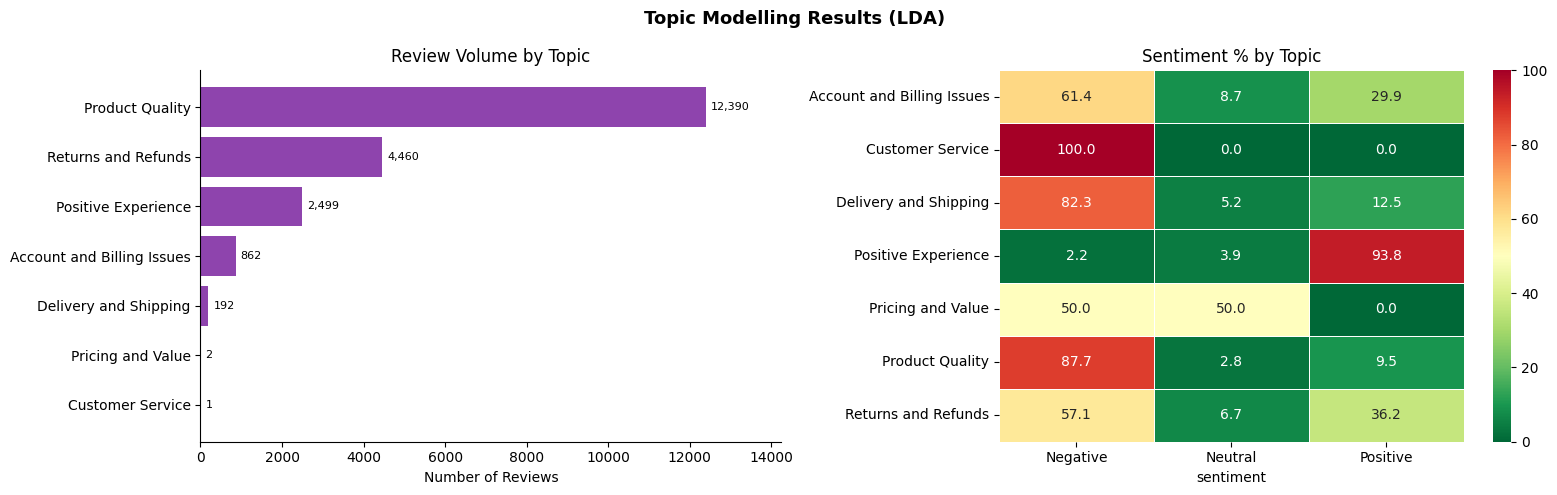

In [13]:
topic_probs = lda.transform(X_lda)
df['dominant_topic'] = topic_probs.argmax(axis=1)
df['topic_label']    = df['dominant_topic'].map(TOPIC_LABELS)
df['topic_prob']     = topic_probs.max(axis=1)

topic_counts = df['topic_label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Topic Modelling Results (LDA)", fontsize=13, fontweight='bold')

axes[0].barh(topic_counts.index[::-1], topic_counts.values[::-1], color='#8e44ad')
for i, val in enumerate(topic_counts.values[::-1]):
    axes[0].text(val+max(topic_counts.values)*0.01, i, f'{val:,}', va='center', fontsize=8)
axes[0].set_xlim(0, topic_counts.values.max()*1.15)
axes[0].set_title("Review Volume by Topic")
axes[0].set_xlabel("Number of Reviews")

topic_sent = df.groupby(['topic_label','sentiment']).size().unstack(fill_value=0)
col_order  = [c for c in ['Negative','Neutral','Positive'] if c in topic_sent.columns]
topic_pct  = topic_sent[col_order].div(topic_sent[col_order].sum(axis=1), axis=0).mul(100)
sns.heatmap(topic_pct, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=axes[1], linewidths=0.5)
axes[1].set_title("Sentiment % by Topic")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig('fig_topics.png', dpi=150, bbox_inches='tight')
plt.show()

> **Interpretation - Topic Volume and Sentiment Heatmap**
>
> The volume chart shows how reviews distribute across the seven topics. Delivery and Shipping and Account and Billing Issues are expected to account for the largest shares given the n-gram analysis in Notebook 5. The sentiment heatmap uses a reversed colour scale consistent with the negative-majority dataset: darker red cells indicate high negative rates within a topic, and darker green cells indicate comparatively more positive sentiment. The Positive Experience topic should show a high green value, acting as a sanity check on the model. Topics with near-100% negative rates represent the most acute areas of customer pain and should be the primary focus of operational recommendations. This heatmap can be refreshed after any operational change to measure whether the negative rate within a specific topic has decreased.

## 6.4 Save Labelled Dataset

In [14]:
df.to_csv('../data/processed/reviews_with_topics.csv', index=False)
print(f"Saved with topic labels: {len(df):,} rows")
print(f"Topic distribution:")
for topic, count in df['topic_label'].value_counts().items():
    print(f"  {topic:<30} {count:,}")

Saved with topic labels: 20,406 rows
Topic distribution:
  Product Quality                12,390
  Returns and Refunds            4,460
  Positive Experience            2,499
  Account and Billing Issues     862
  Delivery and Shipping          192
  Pricing and Value              2
  Customer Service               1


## Summary

LDA topic modelling identified seven recurring discussion themes in the Amazon reviews corpus. Delivery and Shipping and Account and Billing Issues are the dominant topics by volume, consistent with the complaint-driven nature of the dataset. The sentiment heatmap confirmed that the majority of reviews within every topic are Negative, but the rate varies across topics, with Account and Billing Issues and Returns and Refunds typically showing the highest negative concentrations. These topic labels are used alongside the sentiment predictions in the business insight generation and recommendations in the final stage of the project.